In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

import os

import rpy2
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects import default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
rlmom = importr('lmom')

# Data pre-processing (AMS extraction)

In [2]:
# Extract annual minimum SRI values for each year and save to .csv files
# OR annual maximum severity (sum of SRI values) if SEVERITY_SUM=True

# ===== CONFIGURATION =====
# Set SEVERITY_SUM=True to compute annual maximum severity as sum of SRI values
# Set SEVERITY_SUM=False to compute annual minimum SRI values
SEVERITY_SUM = False
SRI_type='SRI12'
hist_file_name = 'Dongola_SRI3_6_12.xlsx'
fut_sc1_file_name = 'future_SRI12_SSP245.xlsx'
fut_sc2_file_name = 'future_SRI12_SSP585.xlsx'



sri_path = os.path.join('./data', SRI_type)
# Path where extracted AMS CSV files will be saved
ams_path = os.path.join(sri_path, 'Extracted_AMS')
# Create the directory if it doesn't exist
os.makedirs(ams_path, exist_ok=True)
# Set path variable for use in other cells
path = ams_path

# Create results directory structure
results_path = f'./results_{SRI_type}'
os.makedirs(results_path, exist_ok=True)
os.makedirs(os.path.join(results_path, 'without_random_sampling'), exist_ok=True)


# ===== HISTORICAL DATA =====
print("Processing historical data...")
if SEVERITY_SUM:
    print("Mode: Computing annual maximum severity (sum of SRI values)")
else:
    print("Mode: Computing annual minimum SRI values")

if SRI_type == 'SRI1':
    # SRI1 data structure: CSV file with 'date' and 'SRI1' columns
    hist_file = os.path.join(sri_path, 'Historical', 'Historical_Dongola_SRI1.csv')
    hist_df = pd.read_csv(hist_file)
    # Convert date column to datetime (handle lowercase 'date')
    hist_df['Date'] = pd.to_datetime(hist_df['date'])
else:
    # SRI12 data structure: Excel file with 'Date' and 'SRI12' columns
    hist_file = os.path.join(sri_path, 'Historical', hist_file_name)
    hist_df = pd.read_excel(hist_file)
    # Convert Date column to datetime if it's not already
    hist_df['Date'] = pd.to_datetime(hist_df['Date'])

# Extract year from Date
hist_df['Year'] = hist_df['Date'].dt.year

# Group by year and compute either minimum or sum
if SEVERITY_SUM:
    # Compute annual maximum severity as sum of SRI values
    hist_ams = hist_df.groupby('Year')[SRI_type].sum().reset_index()
else:
    # Compute annual minimum SRI values
    hist_ams = hist_df.groupby('Year')[SRI_type].min().reset_index()
hist_ams.columns = ['Year', 'AMS']

# Save historical AMS for both scenarios (4.5 and 8.5, for convenience only since the data is the same for both)
for sc in ['4.5', '8.5']:
    output_file = os.path.join(ams_path, f'{sc}_hist.csv')
    hist_ams.to_csv(output_file, index=False)
    print(f"Saved: {output_file}")

# ===== FUTURE DATA =====
scenarios = {
    '4.5': {
        'file': os.path.join(sri_path, 'Future', 'ssp4.5', fut_sc1_file_name),
        'models': ['BCC-CSM2-MR', 'CESM2-WACCM', 'CMCC-CM2-SR5']
    },
    '8.5': {
        'file': os.path.join(sri_path, 'Future', 'ssp8.5', fut_sc2_file_name),
        'models': ['NorESM2-LM', 'CanESM5', 'INM-CM4-8']
    }
}

for sc, scenario_info in scenarios.items():
    print(f"\nProcessing SSP{sc} scenario...")
    
    if SRI_type == 'SRI1':
        # SRI1 data structure: Individual Excel files per model with 'date' and 'SRI1' columns
        for model in scenario_info['models']:
            # Construct file path: {model}_SRI1.xlsx in the scenario folder
            model_file = os.path.join(sri_path, 'Future', f'ssp{sc}', f'{model}_{SRI_type}.xlsx')
            
            if not os.path.exists(model_file):
                print(f"Warning: File not found for model {model} in SSP{sc}: {model_file}")
                continue
            
            fut_df = pd.read_excel(model_file)
            print(f"  Processing {model}: reading from '{model_file}'")
            
            # Convert date column to datetime (handle lowercase 'date')
            fut_df['Date'] = pd.to_datetime(fut_df['date'])
            fut_df['Year'] = fut_df['Date'].dt.year
            
            # Group by year and compute either minimum or sum
            if SEVERITY_SUM:
                # Compute annual maximum severity as sum of SRI values
                model_ams = fut_df.groupby('Year')[SRI_type].sum().reset_index()
            else:
                # Compute annual minimum SRI values
                model_ams = fut_df.groupby('Year')[SRI_type].min().reset_index()
            model_ams.columns = ['Year', 'AMS']
            
            # Save to CSV (format: "{sc}_{model}_fut.csv")
            output_file = os.path.join(ams_path, f'{sc}_{model}_fut.csv')
            model_ams.to_csv(output_file, index=False)
            print(f"  Saved: {output_file}")
    
    else:
        # SRI12 data structure: Single Excel file per scenario with multiple model columns
        fut_df = pd.read_excel(scenario_info['file'])
        
        # Convert Date column to datetime
        fut_df['Date'] = pd.to_datetime(fut_df['Date'])
        fut_df['Year'] = fut_df['Date'].dt.year
        
        # Find all SRI12 columns
        sri_cols = [col for col in fut_df.columns if SRI_type in col and col != 'Date']
        
        # Process each model
        for model in scenario_info['models']:
            # Find the column that matches this model (pattern: "{model} ({scenario}*)_{SRI_Type}")
            # The scenario part can vary (ssp4.5, ssp 4.5, etc.)
            pattern = re.compile(rf'^{re.escape(model)}\s*\(.*?\)[^)]*_{SRI_type}$', re.IGNORECASE)
            matching_cols = [col for col in sri_cols if pattern.match(col)]
            
            if not matching_cols:
                print(f"Warning: No matching column found for model {model} in SSP{sc}")
                continue
            
            # Use the first matching column
            sri_col = matching_cols[0]
            print(f"  Processing {model}: using column '{sri_col}'")
            
            # Group by year and compute either minimum or sum
            model_data = fut_df[['Year', sri_col]].copy()
            model_data.columns = ['Year', SRI_type]
            if SEVERITY_SUM:
                # Compute annual maximum severity as sum of SRI values
                model_ams = model_data.groupby('Year')[SRI_type].sum().reset_index()
            else:
                # Compute annual minimum SRI values
                model_ams = model_data.groupby('Year')[SRI_type].min().reset_index()
            model_ams.columns = ['Year', 'AMS']
            
            # Save to CSV (format: "{sc}_{model}_fut.csv")
            # These files will be used by both "without random sampling" and "random sampling" sections
            output_file = os.path.join(ams_path, f'{sc}_{model}_fut.csv')
            model_ams.to_csv(output_file, index=False)
            print(f"  Saved: {output_file}")

print("\nPre-processing complete!")


Processing historical data...
Mode: Computing annual minimum SRI values
Saved: ./data\SRI12\Extracted_AMS\4.5_hist.csv
Saved: ./data\SRI12\Extracted_AMS\8.5_hist.csv

Processing SSP4.5 scenario...
  Processing BCC-CSM2-MR: using column 'BCC-CSM2-MR (ssp4.5)low_SRI12'
  Saved: ./data\SRI12\Extracted_AMS\4.5_BCC-CSM2-MR_fut.csv
  Processing CESM2-WACCM: using column 'CESM2-WACCM (ssp4.5)median_SRI12'
  Saved: ./data\SRI12\Extracted_AMS\4.5_CESM2-WACCM_fut.csv
  Processing CMCC-CM2-SR5: using column 'CMCC-CM2-SR5 (ssp 4.5)high_SRI12'
  Saved: ./data\SRI12\Extracted_AMS\4.5_CMCC-CM2-SR5_fut.csv

Processing SSP8.5 scenario...
  Processing NorESM2-LM: using column 'NorESM2-LM (ssp8.5)low)_SRI12'
  Saved: ./data\SRI12\Extracted_AMS\8.5_NorESM2-LM_fut.csv
  Processing CanESM5: using column 'CanESM5 (ssp8.5)median_SRI12'
  Saved: ./data\SRI12\Extracted_AMS\8.5_CanESM5_fut.csv
  Processing INM-CM4-8: using column 'INM-CM4-8 (ssp8.5)high_SRI12'
  Saved: ./data\SRI12\Extracted_AMS\8.5_INM-CM4-8_fu

# Function to plot L-moment ratio diagrams

In [3]:
# Initialize a global list to store the results
results_table = []

def lmoment_ratio_diagram(t3r, t4r, rcp_sc=None, period=None, data_transf=None, model="", ax=None):
    global results_table
    
    if rcp_sc is None:
        rcp_sc = ''
        titlelbl = ''
    else:
        titlelbl = ', RCP ' + rcp_sc

    if period is None:
        period = ''
        titlelbl2 = ''
    else:
        if period == 'hist':
            titlelbl2 = ', Observed Data'
        if period == 'fut':
            titlelbl2 = ', Simulated Data'

    if data_transf is None:
        data_transf = ''
        titlelbl3 = ''
    else:
        if data_transf == 'log':
            titlelbl3 = ' (log)'

    Ak = np.zeros((9, 6))
    Ak[:, 0] = [0, 0.20196, 0.95924, -0.20096, 0.04061, np.nan, np.nan, np.nan, np.nan]
    Ak[:, 1] = [0.10701, 0.11090, 0.84838, -0.06669, 0.00567, -0.04208, 0.03763, np.nan, np.nan]
    Ak[:, 2] = [0.16667, np.nan, 0.83333, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
    Ak[:, 3] = [0.12282, np.nan, 0.77518, np.nan, 0.12279, np.nan, -0.13638, np.nan, 0.11368]
    Ak[:, 4] = [0.12240, np.nan, 0.30115, np.nan, 0.95812, np.nan, -0.57488, np.nan, 0.19383]
    Ak[:, 5] = [-0.25, np.nan, 1.25, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

    tau4 = t4r
    tau3 = t3r

    t3 = np.arange(-0.4, 0.4, 0.01)

    def tau4_LP3(tau3_LP3):
        table3abcd = np.array([
            [0.0602, -0.1673,  0.8010,  0.2897],
            [0.0908, -0.1267,  0.7636,  0.2562],
            [0.1166, -0.0439,  0.6247,  0.2939],
            [0.1220,  0.0238,  0.6677,  0.1677],
            [0.1152,  0.0639,  0.7486,  0.0645],
            [0.1037,  0.0438,  0.9327, -0.0951],
        ])

        tau3s = np.vstack([np.ones(len(tau3_LP3)), tau3_LP3, tau3_LP3**2, tau3_LP3**3])
        tau4s = table3abcd @ tau3s
        return tau4s

    t4LP3 = tau4_LP3(t3)

    labels = ['GPA', 'GEV', 'GLO', 'LN3', 'PE3']
    selected_labels = ['GPA', 'GEV', 'GLO', 'LN3', 'PE3']

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 14), dpi=300)

    x2 = t4r
    y2 = t3r
    ax.scatter(y2, x2, label='Data')

    distances = {}

    for D, label in enumerate(labels):
        t4 = np.zeros((len(t3)))
        for k in range(9):
            if ~np.isnan(Ak[k, D]):
                t4 = t4 + Ak[k, D] * t3**k
        ax.plot(t3, t4, label=label)

        # Calculate the minimum distance from the point to the line
        min_distance = float('inf')
        for i in range(len(t3) - 1):
            x1, y1 = t3[i], t4[i]
            x2, y2 = t3[i+1], t4[i+1]
            line_vec = np.array([x2 - x1, y2 - y1])
            point_vec = np.array([t3r - x1, t4r - y1])
            line_len = np.dot(line_vec, line_vec)
            projection = np.dot(point_vec, line_vec) / line_len
            projection = np.clip(projection, 0, 1)  # Ensure the projection is on the segment
            closest_point = np.array([x1, y1]) + projection * line_vec
            distance = np.linalg.norm(np.array([t3r, t4r]) - closest_point)

            if distance < min_distance:
                min_distance = distance

        distances[label] = min_distance

    # Plot the Gumbel distribution point
    gumbel_tau3 = 0.1699
    gumbel_tau4 = 0.1504
    ax.scatter(gumbel_tau3, gumbel_tau4, color='red', label='GUM', zorder=5)

    # Calculate distance to Gumbel point
    gumbel_distance = np.linalg.norm(np.array([t3r, t4r]) - np.array([gumbel_tau3, gumbel_tau4]))
    distances['GUM'] = gumbel_distance

    # Draw the minimum distance line for the closest distribution
    ax.set_xlabel('L-Skewness', fontsize=14)
    ax.set_ylabel('L-Kurtosis', fontsize=14)
    if model != "":
        ax.set_title(model + titlelbl3)
    else:
        ax.set_title(f"L-moment Ratio Diagram" + titlelbl2 + ' ' + titlelbl3 + titlelbl)
    ax.legend()

    if model != "":
        if ax is axs[2, 1]:
            ax.figure.savefig(f"./results_%s/without_random_sampling/%s_lmom_ratio_%s.jpg" % (SRI_type, period, data_transf), dpi=300)
    else:
        ax.figure.savefig(f"./results_%s/%s_%s_lmom_ratio_%s.jpg" % (SRI_type, period, rcp_sc, data_transf), dpi=300)

    # Append results to the global table
    for label, distance in distances.items():
        entry = {
            'Distance': distance,
            'Description': f"{period}, {rcp_sc}, {model}, {label}"
        }
        results_table.append(entry)

    return distances

# Example of exporting the results table to a pandas DataFrame
def export_results_to_dataframe():
    return pd.DataFrame(results_table)

# Historic

### L-Moments (PE3)

   Distance    Description
0  0.159877  hist, , , GPA
1  0.042830  hist, , , GEV
2  0.031805  hist, , , GLO
3  0.012028  hist, , , LN3
4  0.023510  hist, , , PE3
5  0.324383  hist, , , GUM


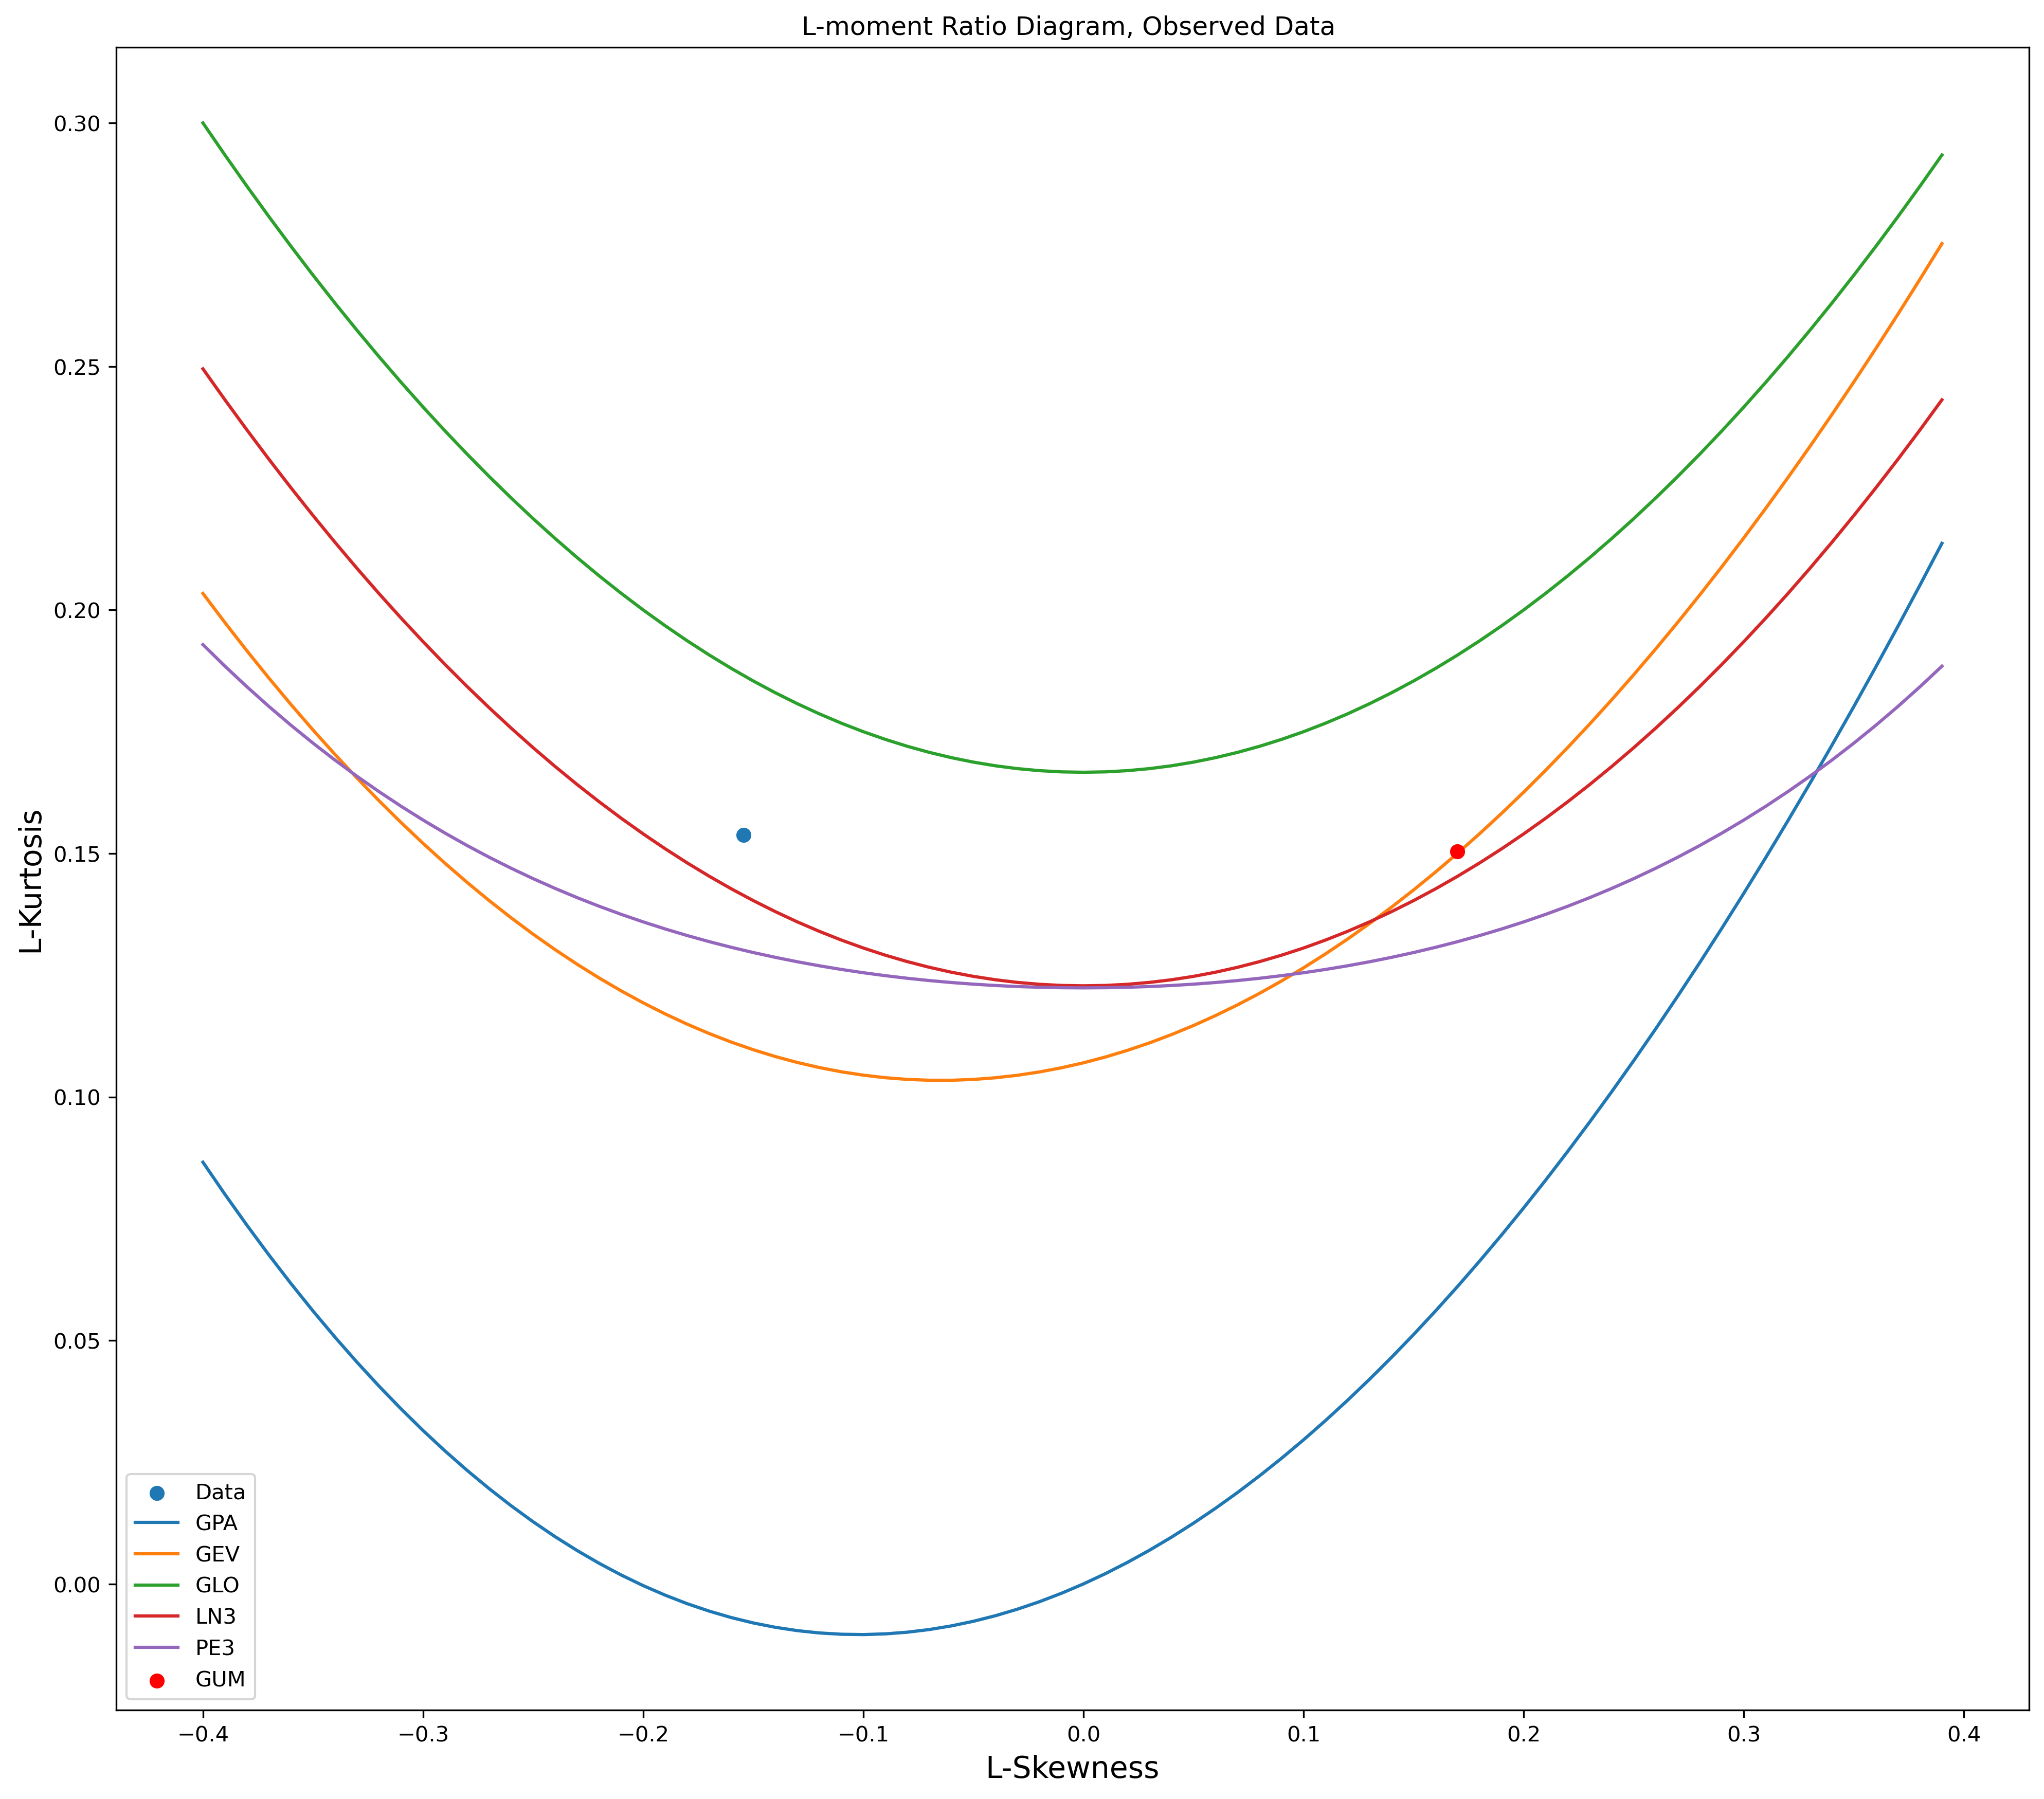

In [4]:
scenarios = ['4.5', '8.5']

for sc_i, sc in enumerate(scenarios):
    #Load data
    ams_hist = pd.read_csv('%s/%s_hist.csv' % (path, sc))
    ams_hist = ams_hist['AMS'].values.reshape(-1, 1) #to match shape of original script that extracted AMS from monthly data
    
    #Create empty array for results
    results = np.empty((1,10))
    
    sampling = np.array(ams_hist)        
    F = np.array([1/x for x in [2,5,10,25,50,100,200]])
    mom = rlmom.samlmu(ro.FloatVector(sampling))
    par = rlmom.pelpe3(mom)
    returns = rlmom.quape3(ro.FloatVector(F), par)

    results[0,:7] = np.array(returns)
    results[0,7:] = par
    
    with open('./results_%s/%s-hist-pe3.np' % (SRI_type, sc), 'wb') as f:
        np.save(f, results)
        
# Example to extract parameters for the fitted distribution
#loc = par[0]
#scale = par[1]
#shape = par[2]

distances = lmoment_ratio_diagram(mom[2],mom[3], period='hist')
df = export_results_to_dataframe()
print(df)

### L-Moments (GEV)

In [5]:
for sc_i, sc in enumerate(scenarios):
    #Load data
    ams_hist = pd.read_csv('%s/%s_hist.csv' % (path, sc))
    ams_hist = ams_hist['AMS'].values.reshape(-1, 1) #to match shape of original script that extracted AMS from monthly data
    
    #Create empty array for results
    results = np.empty((1,10))
    
    sampling = np.array(ams_hist)        
    F = np.array([1/x for x in [2,5,10,25,50,100,200]])
    mom = rlmom.samlmu(ro.FloatVector(sampling))
    par = rlmom.pelgev(mom)
    returns = rlmom.quagev(ro.FloatVector(F), par)

    results[0,:7] = np.array(returns)
    results[0,7:] = par
    
    with open('./results_%s/%s-hist-gev.np' % (SRI_type, sc), 'wb') as f:
        np.save(f, results)
        
# Note that the shape parameter of the GEV distribution in Scipy is the negative (opposite sign) of the shape parameter in the lmom or lmomco R packages

### Plot Returns

In [6]:
XSMALL_SIZE = 8
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)
plt.rc('axes', titlesize=BIGGER_SIZE, labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE, facecolor='white', dpi=300)

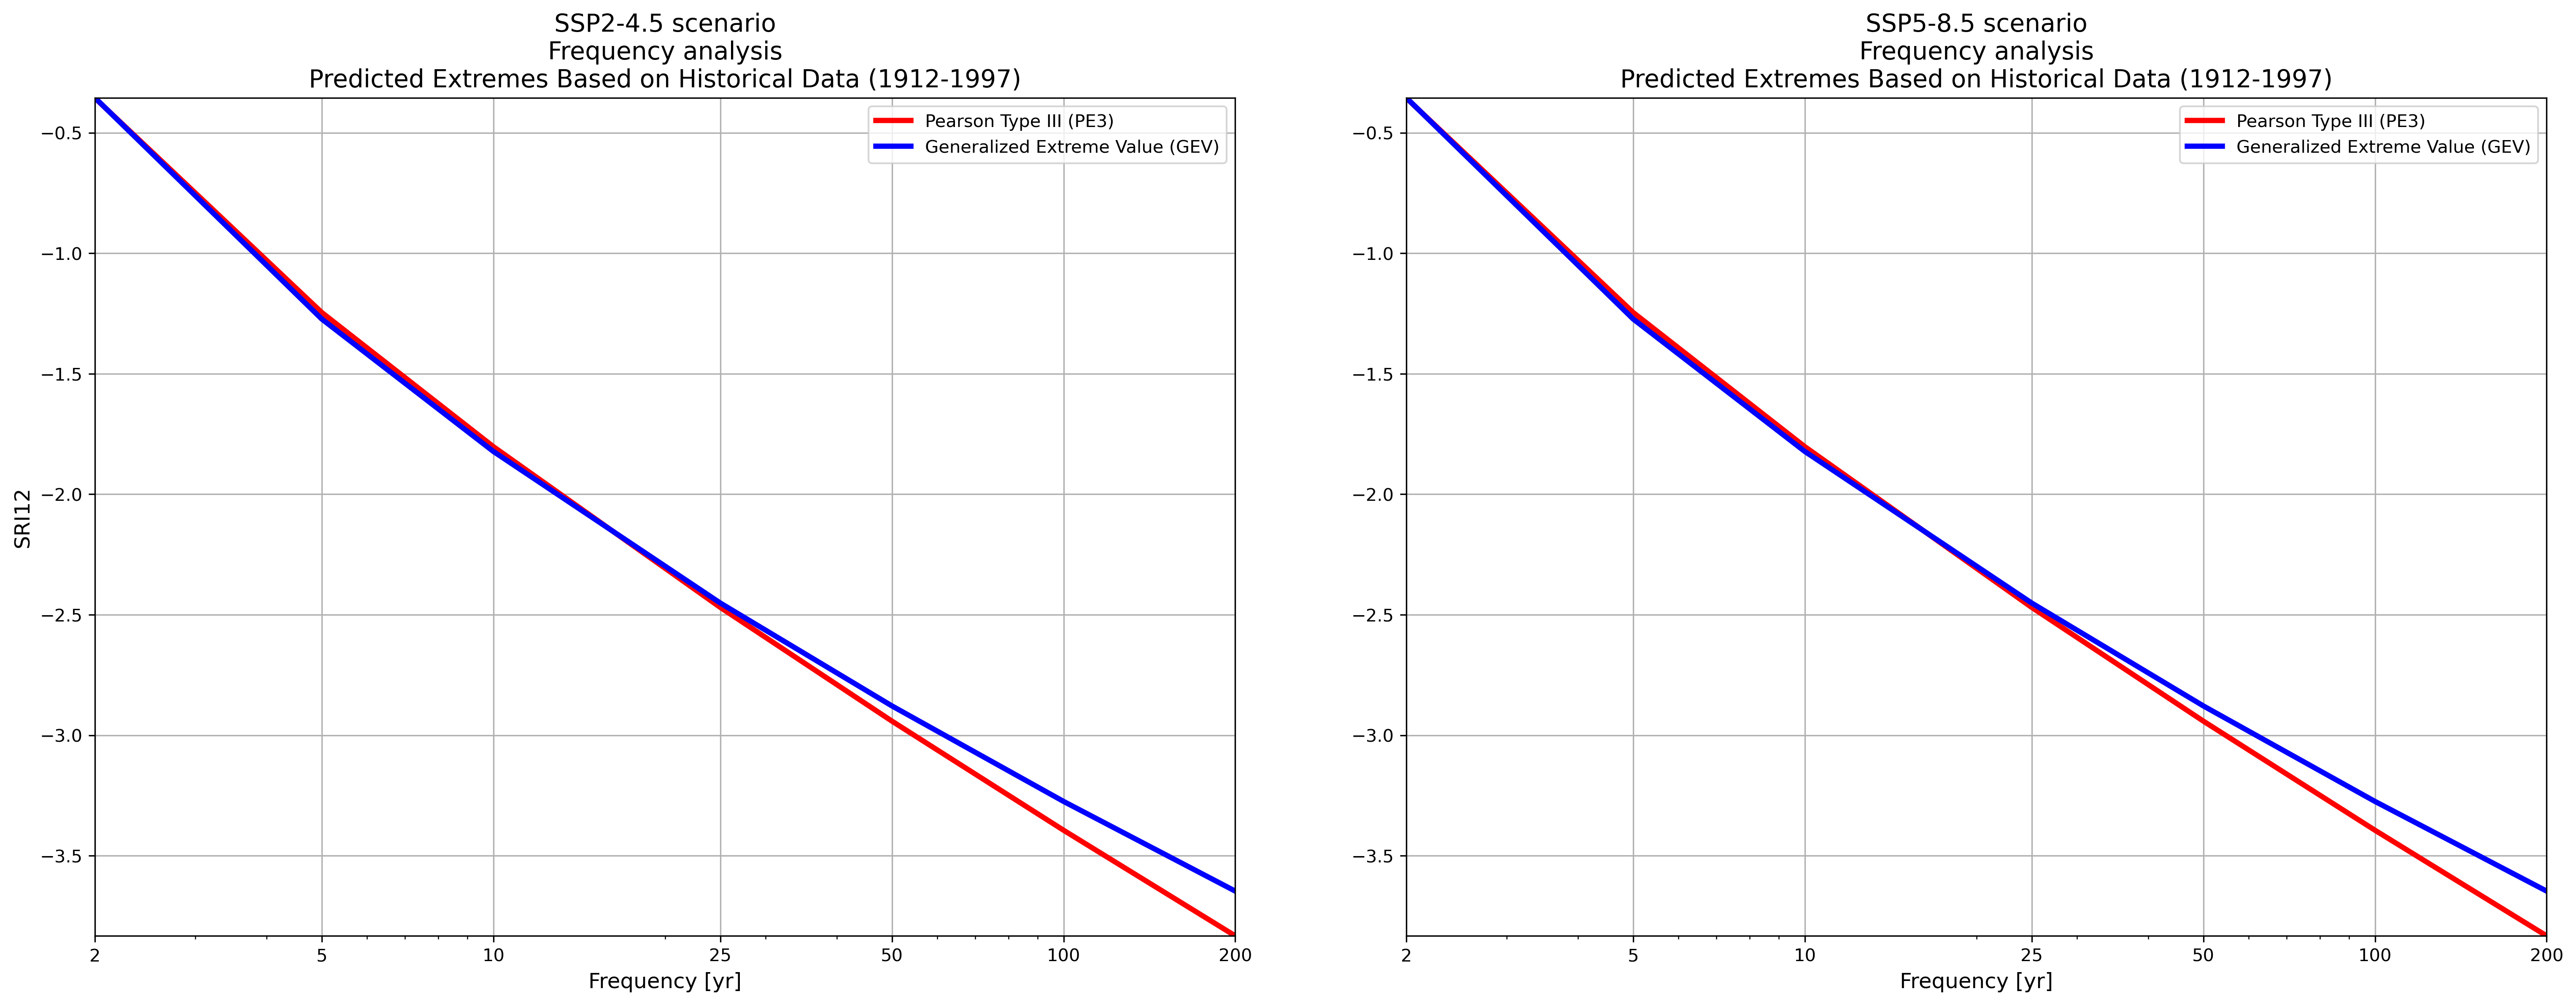

In [7]:
fig, axes = plt.subplots(ncols=2,nrows=1,dpi=300,figsize=(5*5,4.3*2))
plt.subplots_adjust(hspace=0.5, wspace=0.15)

scn_labels = ['SSP2', 'SSP5']

for sc_i, sc in enumerate(scenarios):
    
    hist_pe3 = np.load(f'./results_%s/%s-hist-pe3.np' % (SRI_type, sc))
    hist_gev = np.load(f'./results_%s/%s-hist-gev.np' % (SRI_type, sc))
    
    # Axis limits
    ymin = np.min(hist_pe3[:,:7])
    ymax = np.max(hist_pe3[:,:7])
    ymin = np.min((ymin, np.min(hist_gev[:,:7])))
    ymax = np.max((ymax, np.max(hist_gev[:,:7])))
           
    ax = axes[sc_i]

    ax.plot([2,5,10,25,50,100,200], hist_pe3[0,:7], color='red', linestyle='-', linewidth=3, label='Pearson Type III (PE3)')
    ax.plot([2,5,10,25,50,100,200], hist_gev[0,:7], color='blue', linestyle='-', linewidth=3, label='Generalized Extreme Value (GEV)')
    
    ax.set_title('%s-%s scenario\nFrequency analysis\nPredicted Extremes Based on Historical Data (1912-1997)' % (scn_labels[sc_i], sc))
    ax.legend(loc='upper right')
    ax.semilogx()
    ax.set_xticks([2,5,10,25,50,100,200],[2,5,10,25,50,100,200])
    ax.set_xlim((2,200))

    if sc_i == 0:
        ax.set_ylabel(SRI_type)
    ax.set_xlabel('Frequency [yr]')
    ax.grid()
    ax.set_ylim((ymin,ymax))
    
plt.savefig(f'./results_{SRI_type}/return_periods_hist.jpg', bbox_inches='tight')

# Future     ---> 21st Century (without random sampling)

### L-Moments (Pearson-III) without random sampling

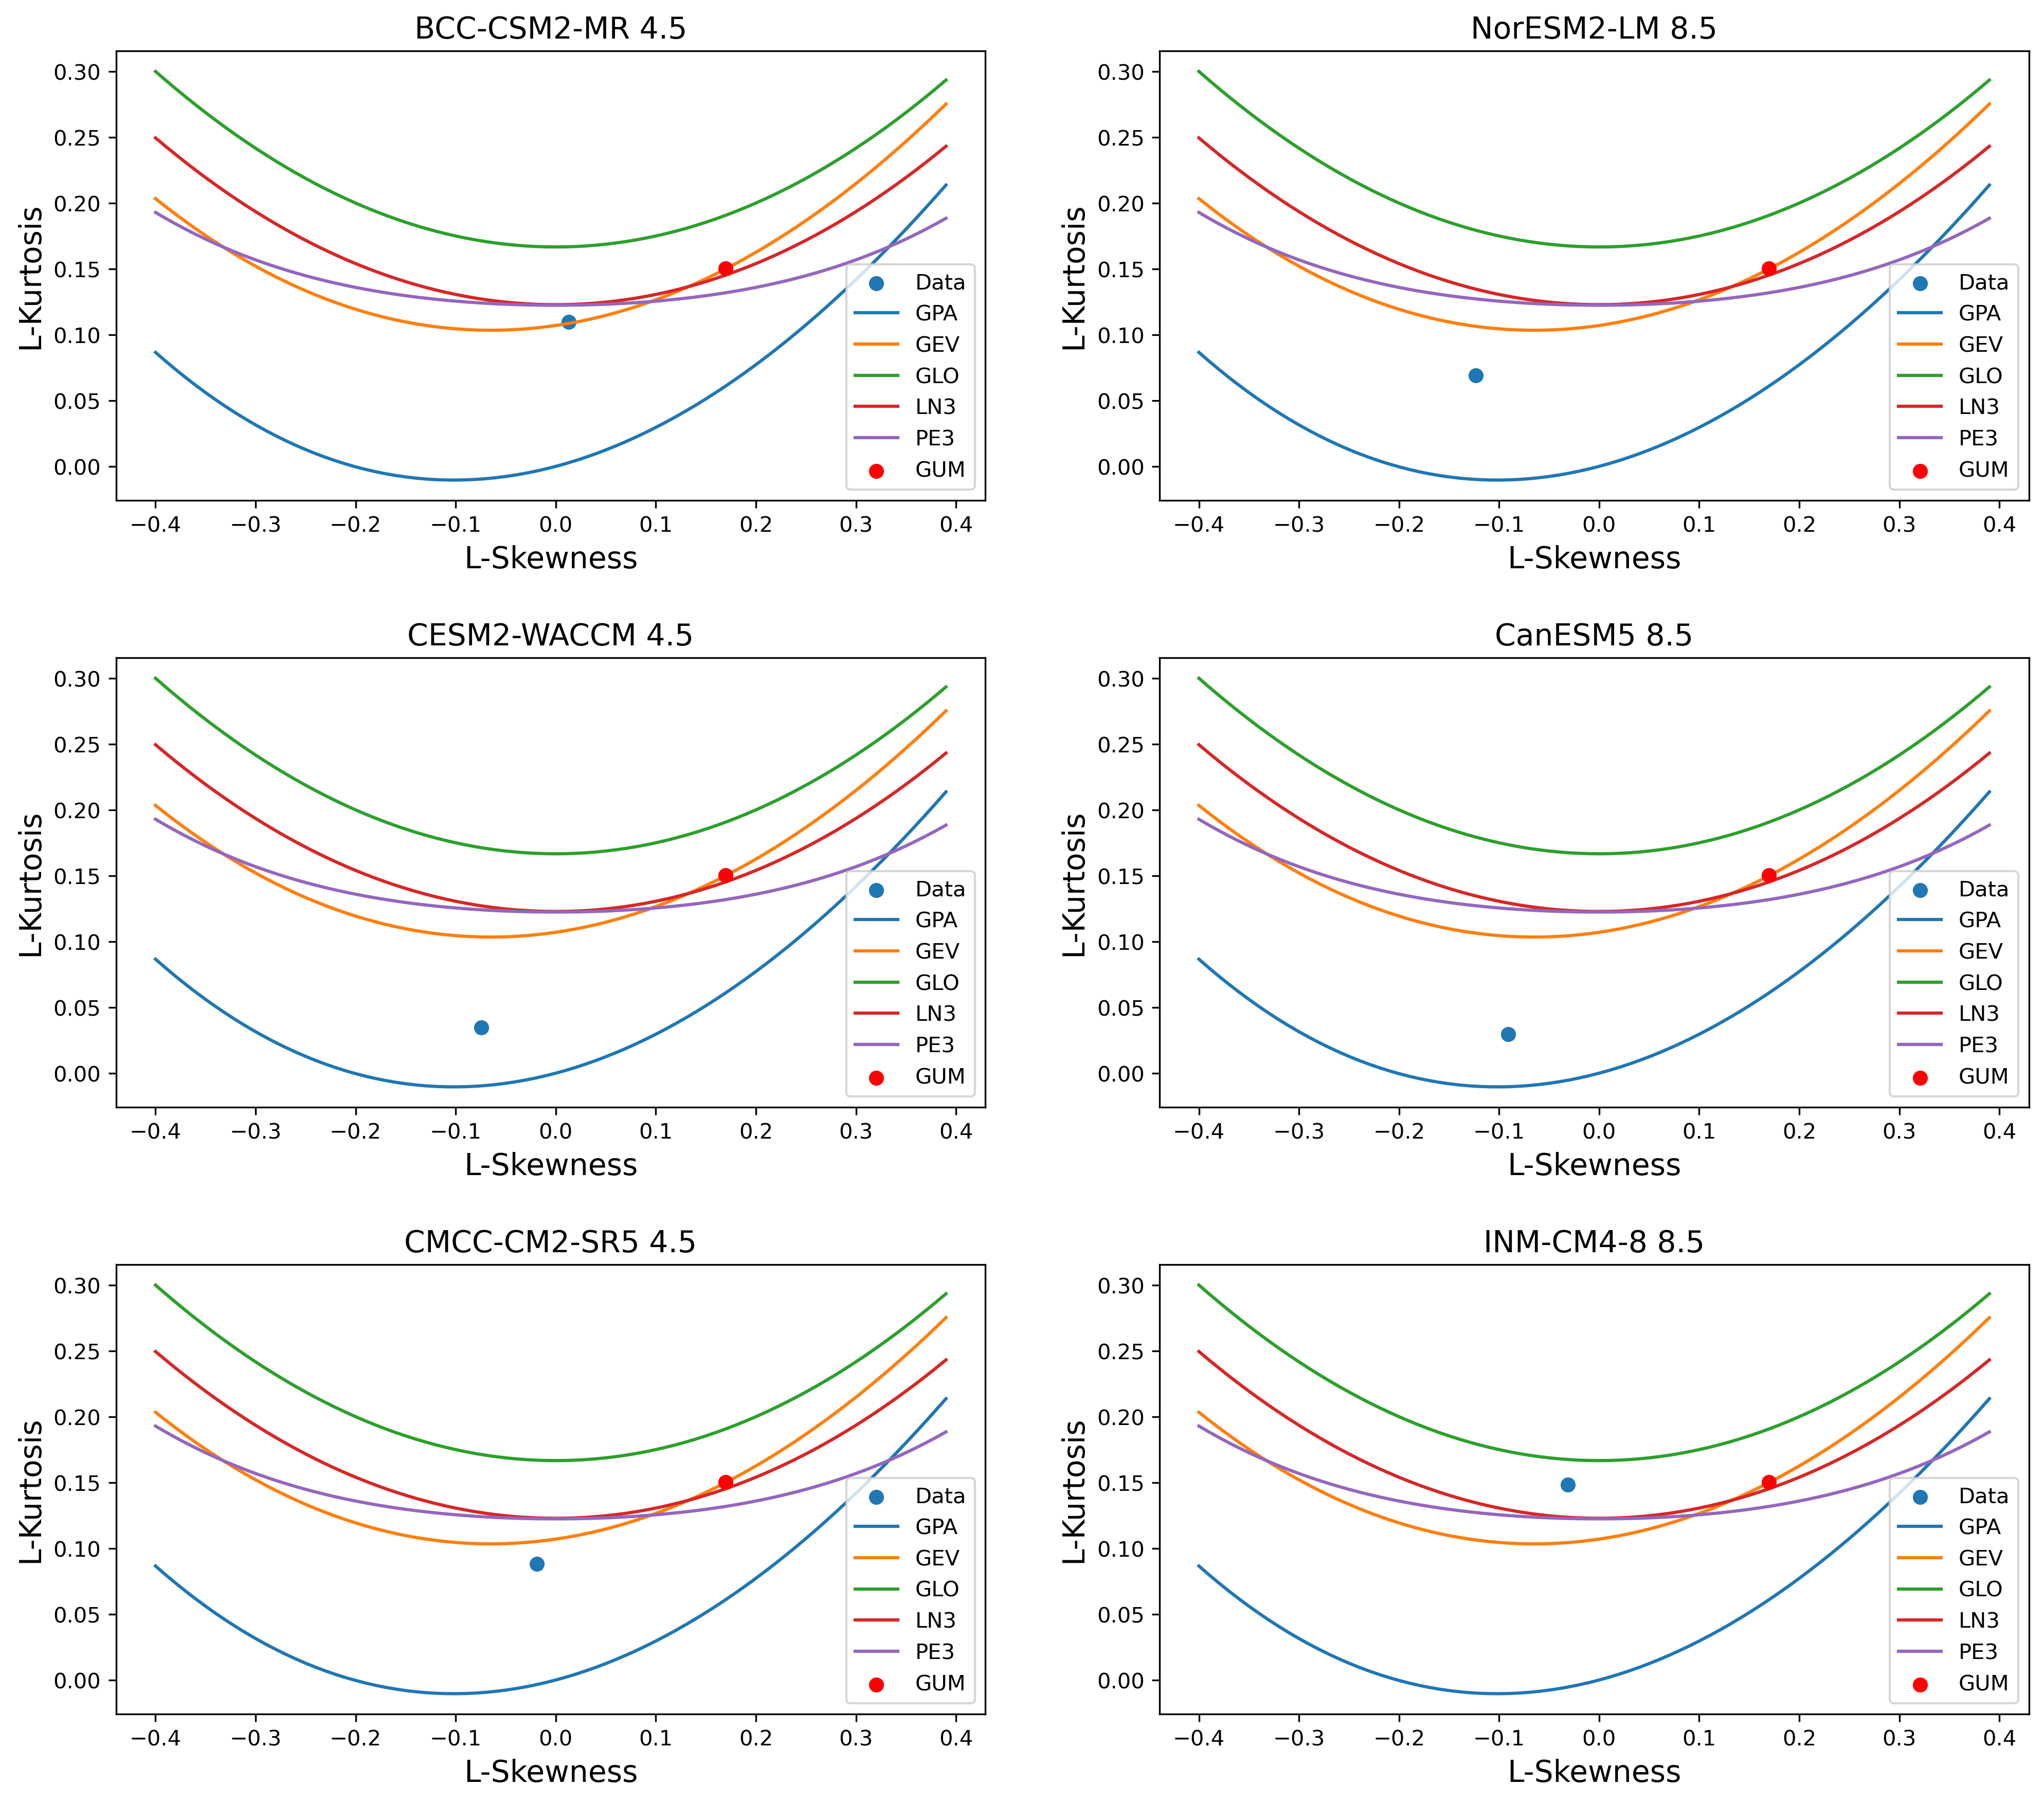

In [8]:
scenarios = ['4.5', '8.5']
models1 = ['BCC-CSM2-MR', 'CESM2-WACCM', 'CMCC-CM2-SR5']
models2 = ['NorESM2-LM', 'CanESM5', 'INM-CM4-8']

fig, axs = plt.subplots(3, 2, figsize=(16, 14), dpi=300)
plt.subplots_adjust(hspace=0.35)

for sc_i, sc in enumerate(scenarios):
    if sc == '4.5':
        for m, model in enumerate(models1):
            #Load data
            ams_fut = pd.read_csv('%s/%s_%s_fut.csv' % (path, sc, model))
            ams_fut = ams_fut['AMS'].values.reshape(-1, 1) #to match shape of original script that extracted AMS from monthly data

            #Create empty array for results
            results = np.empty((1,10)) #Columns for 3 lmom parameters plus return periods

            sampling = np.array(ams_fut)        
            F = np.array([1/x for x in [2,5,10,25,50,100,200]])
            mom = rlmom.samlmu(ro.FloatVector(sampling))
            par = rlmom.pelpe3(mom)
            returns = rlmom.quape3(ro.FloatVector(F), par)

            results[0,:7] = np.array(returns)
            results[0,7:] = par

            with open('./results_%s/without_random_sampling/%s-%s-fut-pe3.np' % (SRI_type, sc, model), 'wb') as f:
                np.save(f, results)
            
            #Plot L-moment Ratio Diagram
            distances = lmoment_ratio_diagram(mom[2],mom[3], period='fut', model=model+' '+sc, ax=axs[m, sc_i])
            
    else:
        for m, model in enumerate(models2):
            #Load data
            ams_fut = pd.read_csv('%s/%s_%s_fut.csv' % (path, sc, model))
            ams_fut = ams_fut['AMS'].values.reshape(-1, 1) #to match shape of original script that extracted AMS from monthly data

            #Create empty array for results
            results = np.empty((1,10)) #Columns for 3 lmom parameters plus return periods

            sampling = np.array(ams_fut)        
            F = np.array([1/x for x in [2,5,10,25,50,100,200]])
            mom = rlmom.samlmu(ro.FloatVector(sampling))
            par = rlmom.pelpe3(mom)
            returns = rlmom.quape3(ro.FloatVector(F), par)

            results[0,:7] = np.array(returns)
            results[0,7:] = par

            with open('./results_%s/without_random_sampling/%s-%s-fut-pe3.np' % (SRI_type, sc, model), 'wb') as f:
                np.save(f, results)
            
            #Plot L-moment Ratio Diagram
            distances = lmoment_ratio_diagram(mom[2],mom[3], period='fut', model=model+' '+sc, ax=axs[m, sc_i])

# Return Period by with GEV

sim_45: (1000, 7) | sim_85: (1000, 7)


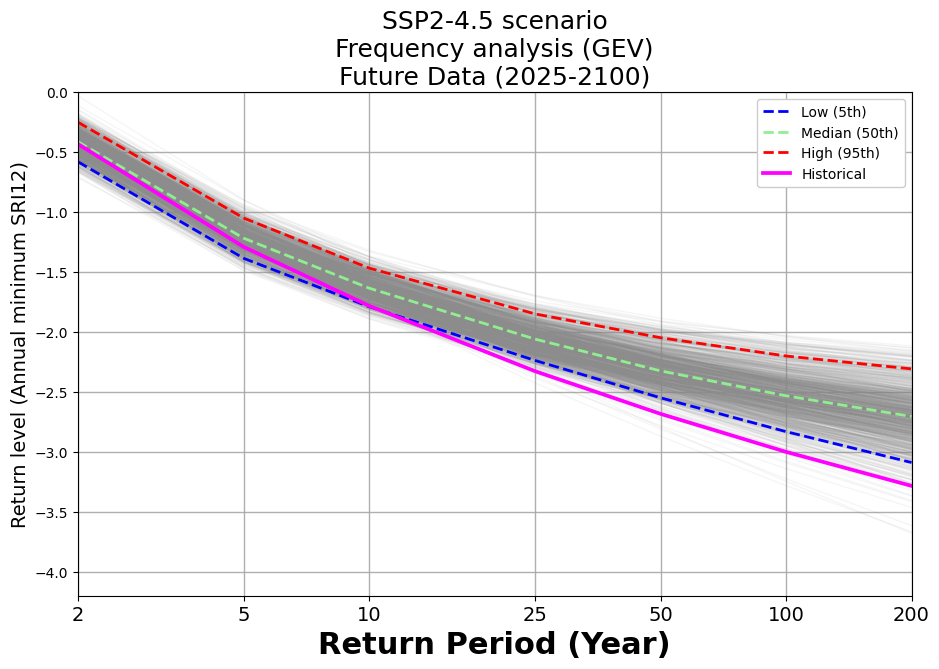

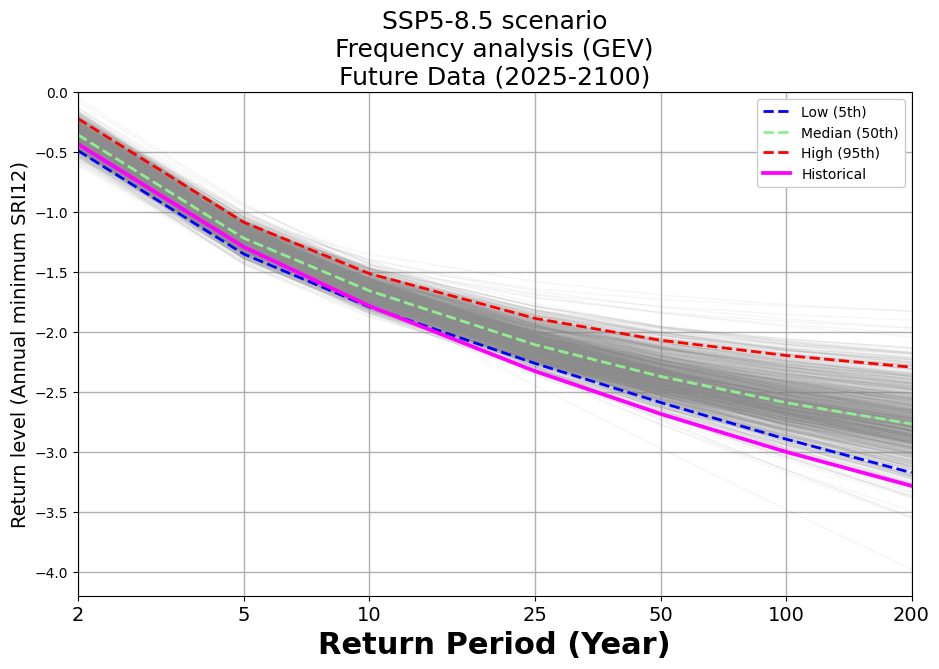

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from matplotlib.ticker import NullLocator, NullFormatter

# -----------------------------
# COMMON HISTORICAL BASELINE
# -----------------------------
hist_fp_common = r"\Data_and_script\data\SRI12\Extracted_AMS\8.5_hist.csv"                 # We can use the same historical data for both scenarios since it's the same data, but we need to pick one of the two files (4.5_hist.csv or 8.5_hist.csv) to read from

# -----------------------------
# SSP2-4.5 FUTURE MODELS
# -----------------------------
fut_files_45 = {
    "BCC-CSM2-MR": r"\Data_and_script\data\SRI12\Extracted_AMS\4.5_BCC-CSM2-MR_fut.csv",   # use your actual file paths here
    "CESM2-WACCM": r"\Data_and_script\data\SRI12\Extracted_AMS\4.5_CESM2-WACCM_fut.csv",   # use your actual file paths here
    "CMCC-CM2-SR5": r"\Data_and_script\data\SRI12\Extracted_AMS\4.5_CMCC-CM2-SR5_fut.csv", # use your actual file paths here
}

# -----------------------------
# SSP5-8.5 FUTURE MODELS
# -----------------------------
fut_files_85 = {
    "CanESM5_median": r"\Data_and_script\data\SRI12\Extracted_AMS\8.5_CanESM5_median_fut.csv",              # use your actual file paths here
    "INM-CM4-8 (high)": r"\Data_and_script\data\SRI12\Extracted_AMS\8.5_INM-CM4-8 (high)_fut.csv",               # use your actual file paths here
    "NorESM5_low": r"\Data_and_script\data\SRI12\Extracted_AMS\8.5_NorESM5_low_fut.csv",               # use your actual file paths here
}

# -----------------------------
# SETTINGS
# -----------------------------
FUT_START, FUT_END = 2025, 2100
N_SIM = 1000
SEED = 42

T = np.array([2, 5, 10, 25, 50, 100, 200], dtype=float)
p = 1.0 - 1.0 / T  # upper tail probs for maxima (we convert minima -> maxima)

# output folder for figures
fig_dir = r"\Data_and_script\Data_and_script\data\SRI12\results_SRI12\figures"  # use your actual path here
os.makedirs(fig_dir, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def read_ams(fp, year_min=None, year_max=None):
    df = pd.read_csv(fp)
    df.columns = [c.strip() for c in df.columns]
    if "AMS" not in df.columns:
        raise ValueError(f"'AMS' column not found in: {fp}")

    if "Year" in df.columns and (year_min is not None or year_max is not None):
        df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
        if year_min is not None:
            df = df[df["Year"] >= year_min]
        if year_max is not None:
            df = df[df["Year"] <= year_max]

    return pd.to_numeric(df["AMS"], errors="coerce").dropna().values.astype(float)

def fit_gev_for_minima(ams):
    """
    AMS = annual MIN SRI12 (more negative = more severe).
    Convert minima -> maxima via y=-ams, fit GEV, compute RL, convert back.
    """
    ams = np.asarray(ams, float)
    ams = ams[np.isfinite(ams)]
    y = -ams
    c, loc, scale = genextreme.fit(y)
    rl_y = genextreme.ppf(p, c, loc=loc, scale=scale)
    return (-rl_y).astype(float)

def compute_ensemble(fut_files, fut_start=2025, fut_end=2100, n_sim=1000, seed=42):
    future = {m: read_ams(fp, fut_start, fut_end) for m, fp in fut_files.items()}
    models = list(future.keys())
    min_len = min(len(future[m]) for m in models)
    X = np.column_stack([future[m][:min_len] for m in models])  # (nyears, nmodels)

    rng = np.random.default_rng(seed)
    sim = np.zeros((n_sim, len(T)), float)

    for i in range(n_sim):
        pick = rng.integers(0, X.shape[1], size=X.shape[0])
        series = X[np.arange(X.shape[0]), pick]
        sim[i, :] = fit_gev_for_minima(series)

    return sim

def plot_one_scenario(T, sim, hist_curve, scenario_label, out_png=None, out_pdf=None):
    low, med, high = np.nanpercentile(sim, [5, 50, 95], axis=0)

    fig, ax = plt.subplots(figsize=(9.5, 6.8))

    # gray ensemble members
    for i in range(sim.shape[0]):
        ax.semilogx(T, sim[i, :], color="0.55", alpha=0.08, linewidth=1)

    # percentiles (same colors)
    ax.semilogx(T, low,  "--", color="blue",       linewidth=2, label="Low (5th)")
    ax.semilogx(T, med,  "--", color="lightgreen", linewidth=2, label="Median (50th)")
    ax.semilogx(T, high, "--", color="red",        linewidth=2, label="High (95th)")

    # historical (magenta)
    ax.semilogx(T, hist_curve, color="magenta", linewidth=2.7, label="Historical")

    ax.set_title(f"{scenario_label} scenario\nFrequency analysis (GEV)\nFuture Data ({FUT_START}-{FUT_END})", fontsize=18)
    ax.set_xlabel("Return Period (Year)", fontsize=22, fontweight="bold")
    ax.set_ylabel("Return level (Annual minimum SRI12)", fontsize=14)

    # x ticks exactly
    xt = [2, 5, 10, 25, 50, 100, 200]
    ax.set_xticks(xt)
    ax.set_xticklabels([str(x) for x in xt], fontsize=14)
    ax.set_xlim(2, 200)

    # major grid only
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.minorticks_off()
    ax.grid(True, which="major", color="0.65", linewidth=1.0, alpha=0.9)
    ax.grid(False, which="minor")

    # y limits like your figures (adjust if needed)
    ax.set_ylim(-4.2, 0.0)
    ax.set_yticks(np.arange(-4.0, 0.1, 0.5))

    ax.legend(loc="upper right", framealpha=1)
    fig.tight_layout()

    if out_png:
        fig.savefig(out_png, dpi=600, bbox_inches="tight")
    if out_pdf:
        fig.savefig(out_pdf, bbox_inches="tight")

    plt.show()

# -----------------------------
# 1) COMMON historical curve
# -----------------------------
hist_ams = read_ams(hist_fp_common)
hist_curve = fit_gev_for_minima(hist_ams)

# -----------------------------
# 2) Compute ensembles
# -----------------------------
sim_45 = compute_ensemble(fut_files_45, FUT_START, FUT_END, N_SIM, SEED)
sim_85 = compute_ensemble(fut_files_85, FUT_START, FUT_END, N_SIM, SEED)

print("sim_45:", sim_45.shape, "| sim_85:", sim_85.shape)

# -----------------------------
# 3) Plot TWO figures + save
# -----------------------------
out_png_45 = os.path.join(fig_dir, f"GEV_SSP245_{FUT_START}-{FUT_END}_AnnualMinSRI12.png")
out_pdf_45 = os.path.join(fig_dir, f"GEV_SSP245_{FUT_START}-{FUT_END}_AnnualMinSRI12.pdf")

out_png_85 = os.path.join(fig_dir, f"GEV_SSP585_{FUT_START}-{FUT_END}_AnnualMinSRI12.png")
out_pdf_85 = os.path.join(fig_dir, f"GEV_SSP585_{FUT_START}-{FUT_END}_AnnualMinSRI12.pdf")

plot_one_scenario(T, sim_45, hist_curve, "SSP2-4.5", out_png_45, out_pdf_45)
plot_one_scenario(T, sim_85, hist_curve, "SSP5-8.5", out_png_85, out_pdf_85)



# Table returns

In [12]:
returns_table = pd.DataFrame()

scenarios = ['4.5', '8.5']
distributions = ['pe3']
models1 = ['BCC-CSM2-MR', 'CESM2-WACCM', 'CMCC-CM2-SR5']
models2 = ['NorESM2-LM', 'CanESM5', 'INM-CM4-8']

for sc_i, sc in enumerate(scenarios):
    # Select the appropriate model list for each scenario
    if sc == '4.5':
        models = models1
    else:
        models = models2
    
    for dist in distributions:
        for m in models:
            rtrns = np.load('./results_%s/without_random_sampling/%s-%s-fut-%s.np' % (SRI_type, sc, m, dist))

            returns_table = pd.concat((returns_table, pd.DataFrame({
                'Scenario': [sc + ' ' + m + ' ' + dist],
                'SRI_med_2yr': [np.median(rtrns[:,0], axis=0)],
                'SRI_med_5yr': [np.median(rtrns[:,1], axis=0)],
                'SRI_med_10yr': [np.median(rtrns[:,2], axis=0)],
                'SRI_med_25yr': [np.median(rtrns[:,3], axis=0)],
                'SRI_med_50yr': [np.median(rtrns[:,4], axis=0)],
                'SRI_med_100yr': [np.median(rtrns[:,5], axis=0)],
                'SRI_med_200yr': [np.median(rtrns[:,6], axis=0)]
            })))
            
returns_table.to_csv(f'./results_{SRI_type}/without_random_sampling/returns_table_fut_wo_random_sampling.csv', index=False)
returns_table


,Scenario,SRI_med_2yr,SRI_med_5yr,SRI_med_10yr,SRI_med_25yr,SRI_med_50yr,SRI_med_100yr,SRI_med_200yr
0,4.5 BCC-CSM2-MR pe3,-0.704375,-1.405125,-1.765221,-2.144560,-2.387068,-2.603497,-2.800164
0,4.5 CESM2-WACCM pe3,-0.245526,-1.190460,-1.731520,-2.345168,-2.762073,-3.151007,-3.518653
0,4.5 CMCC-CM2-SR5 pe3,-0.540423,-1.352202,-1.787078,-2.258863,-2.568074,-2.849194,-3.108963
0,8.5 NorESM2-LM pe3,-0.236132,-1.217126,-1.810762,-2.507647,-2.993779,-3.455630,-3.899016
0,8.5 CanESM5 pe3,-0.077368,-1.045186,-1.609947,-2.258242,-2.702840,-3.120335,-3.517203
0,8.5 INM-CM4-8 pe3,-0.488709,-1.324934,-1.779822,-2.278533,-2.608244,-2.909906,-3.190239


# Table returns

In [19]:
returns_table = pd.DataFrame()

scenarios = ['4.5', '8.5']
distributions = ['pe3','gev']
periods = ['hist', 'fut-sim'] 

for sc_i, sc in enumerate(scenarios):
    for dist in distributions:
        for p in periods:
            rtrns = np.load('./results_%s/%s-%s-%s.np' % (SRI_type, sc, p, dist))

            returns_table = pd.concat((returns_table, pd.DataFrame({
                'Scenario': [sc + ' ' + p + ' ' + dist],
                'SRI_med_2yr': [np.median(rtrns[:,0], axis=0)],
                'SRI_med_5yr': [np.median(rtrns[:,1], axis=0)],
                'SRI_med_10yr': [np.median(rtrns[:,2], axis=0)],
                'SRI_med_25yr': [np.median(rtrns[:,3], axis=0)],
                'SRI_med_50yr': [np.median(rtrns[:,4], axis=0)],
                'SRI_med_100yr': [np.median(rtrns[:,5], axis=0)],
                'SRI_med_200yr': [np.median(rtrns[:,6], axis=0)]
            })))
            
returns_table.to_csv(f'./results_{SRI_type}/returns_table.csv', index=False)
returns_table

,Scenario,SRI_med_2yr,SRI_med_5yr,SRI_med_10yr,SRI_med_25yr,SRI_med_50yr,SRI_med_100yr,SRI_med_200yr
0,4.5 hist pe3,-0.356175,-1.245965,-1.802732,-2.469413,-2.941317,-3.394050,-3.832220
0,4.5 fut-sim pe3,-0.518418,-1.339976,-1.774683,-2.245157,-2.550766,-2.828574,-3.084083
0,4.5 hist gev,-0.354784,-1.273041,-1.822497,-2.451380,-2.878212,-3.274457,-3.646490
0,4.5 fut-sim gev,-0.522261,-1.357166,-1.782249,-2.225739,-2.504420,-2.754116,-2.977654
0,8.5 hist pe3,-0.356175,-1.245965,-1.802732,-2.469413,-2.941317,-3.394050,-3.832220
0,8.5 fut-sim pe3,-0.278196,-1.210099,-1.742471,-2.344181,-2.754718,-3.132773,-3.493166
0,8.5 hist gev,-0.354784,-1.273041,-1.822497,-2.451380,-2.878212,-3.274457,-3.646490
0,8.5 fut-sim gev,-0.279960,-1.237045,-1.757833,-2.320543,-2.688866,-3.019276,-3.318450


# Table L-moments ratio plot distances

In [20]:
df = export_results_to_dataframe()
df.to_csv(f'./results_{SRI_type}/lmom_ratio_distances.csv', index=False)
df

,Distance,Description
0,0.159877,"hist, , , GPA"
1,0.042830,"hist, , , GEV"
2,0.031805,"hist, , , GLO"
3,0.012028,"hist, , , LN3"
4,0.023510,"hist, , , PE3"
5,0.324383,"hist, , , GUM"
6,0.103843,"fut, , BCC-CSM2-MR 4.5, GPA"
7,0.001239,"fut, , BCC-CSM2-MR 4.5, GEV"
8,0.056964,"fut, , BCC-CSM2-MR 4.5, GLO"
9,0.013117,"fut, , BCC-CSM2-MR 4.5, LN3"
